In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import csv
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from tqdm import tqdm


from scipy.stats import f_oneway
from scipy.stats import sem, t
from scipy.stats import gaussian_kde
from scipy.stats import norm
from statsmodels.formula.api import mixedlm
from statsmodels.regression.mixed_linear_model import MixedLM
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MinMaxScaler


from matplotlib import gridspec
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.lines import Line2D




In [2]:
df_twitter = pd.read_csv("data/twitter_nhb.csv")

print(df_twitter.keys())
df_twitter

C:\Users\peers\AppData\Local\Temp\ipykernel_33812\3227439951.py:1: DtypeWarning: Columns (3,4,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_twitter = pd.read_csv("data/twitter_nhb.csv")


Index(['id', 'author_id', 'created_at', 'party', 'reply', 'text',
       'retweet_count', 'reply_count', 'like_count', 'expanded_urls',
       'retweeted', 'quote_count', 'text_clean', 'length',
       'evidence_score_w2vparliament', 'intuition_score_w2vparliament',
       'length_bin', 'evidence_mean_w2vparliament',
       'evidence_adj_w2vparliament', 'intuition_mean_w2vparliament',
       'intuition_adj_w2vparliament', 'evidence_z_w2vparliament',
       'intuition_z_w2vparliament', 'emi_w2vparliament',
       'evidence_score_w2vfasttext', 'intuition_score_w2vfasttext',
       'evidence_mean_w2vfasttext', 'evidence_adj_w2vfasttext',
       'intuition_mean_w2vfasttext', 'intuition_adj_w2vfasttext',
       'evidence_z_w2vfasttext', 'intuition_z_w2vfasttext', 'emi_w2vfasttext',
       'leaning'],
      dtype='object')


,id,author_id,created_at,party,reply,text,retweet_count,reply_count,like_count,expanded_urls,...,evidence_score_w2vfasttext,intuition_score_w2vfasttext,evidence_mean_w2vfasttext,evidence_adj_w2vfasttext,intuition_mean_w2vfasttext,intuition_adj_w2vfasttext,evidence_z_w2vfasttext,intuition_z_w2vfasttext,emi_w2vfasttext,leaning
0,1503680985224949766,1.419751e+18,2022-03-15 10:34:18+00:00,NaN,False,Die Planungen zum #Infektionsschutzgesetz sehe...,3.0,9.0,41.0,['https://twitter.com/FBsirske/status/15036809...,...,0.713237,0.669155,0.576861,0.136376,0.561709,0.107445,0.871863,0.707156,0.164707,NaN
1,1503325058781044739,1.419751e+18,2022-03-14 10:59:59+00:00,NaN,True,Was stattdessen wirklich hilft: Ein #Energiege...,4.0,6.0,34.0,[],...,0.646608,0.648621,0.452997,0.193611,0.442066,0.206555,1.237768,1.359450,-0.121682,NaN
2,1503324790811205635,1.419751e+18,2022-03-14 10:58:55+00:00,NaN,False,Menschen kämpfen mit ihren Rechnungen für Heiz...,8.0,5.0,46.0,[],...,0.652212,0.645550,0.576861,0.075351,0.561709,0.083840,0.481722,0.551798,-0.070076,NaN
3,1503071011461283841,1.419751e+18,2022-03-13 18:10:29+00:00,NaN,True,@IngeHannemann Ich setze mich für ein Energieg...,2.0,2.0,8.0,[],...,0.575348,0.556926,0.576861,-0.001513,0.561709,-0.004783,-0.009676,-0.031482,0.021806,NaN
4,1503030431985328137,1.419751e+18,2022-03-13 15:29:14+00:00,NaN,False,Wir brauchen schnell eine bessere soziale Entl...,18.0,7.0,93.0,['https://twitter.com/wazwolfsburg/status/1502...,...,0.693597,0.674276,0.576861,0.116736,0.561709,0.112566,0.746299,0.740859,0.005440,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4651776,1479350244286545920,2.456231e+09,2022-01-07 07:12:37+00:00,The Left Party,NaN,RT @LivaneliZulfu: Bir Başka Tepeden\nSana dün...,48.0,0.0,0.0,[],...,0.011793,0.065175,0.576861,-0.565068,0.561709,-0.496534,-3.612516,-3.267960,-0.344555,left
4651777,1477927160312700929,2.456231e+09,2022-01-03 08:57:48+00:00,The Left Party,NaN,RT @ismailsaymaz: Güya dolar düşünce fiyatlar ...,4280.0,0.0,0.0,[],...,0.026596,0.057028,0.576861,-0.550265,0.561709,-0.504681,-3.517877,-3.321580,-0.196297,left
4651778,1477926800470720514,2.456231e+09,2022-01-03 08:56:22+00:00,The Left Party,NaN,RT @ErcmentAkdeniz: Gözyaşı yetmez! \nSınırda ...,104.0,0.0,0.0,[],...,0.312132,0.369831,0.576861,-0.264729,0.561709,-0.191878,-1.692430,-1.262854,-0.429576,left
4651779,1477926461080313857,2.456231e+09,2022-01-03 08:55:01+00:00,The Left Party,NaN,"RT @LivaneliZulfu: Tweet kolaycılığı, düşünmes...",163.0,0.0,0.0,[],...,0.333102,0.300644,0.576861,-0.243759,0.561709,-0.261065,-1.558365,-1.718209,0.159845,left


In [12]:
df_twitter["party"].unique()


array(['SPD', 'Alliance 90/The Greens', 'FDP', 'CDU/CSU',
       'The Left Party', 'AFD', nan], dtype=object)

In [3]:
df_parliament = pd.read_csv("data/parliament_nhb.csv")

df_parliament['emi_w2vparliament'] = pd.to_numeric(df_parliament['emi_w2vparliament'], errors='coerce')
# Ensure `video_published_at` is in numeric format (e.g., Unix timestamp or days since the start of data)
df_parliament['date'] = pd.to_datetime(
    df_parliament['date'],
    errors='coerce',   # invalid formats become NaT
    utc=True           # ensures consistent timezone handling
)


#df_videos['time_numeric'] = df_videos['video_published_at'].dt.strftime('%Y%m%d').astype(int)
df_parliament['time_numeric'] = pd.to_datetime(df_parliament['date']).dt.strftime('%Y%m%d').astype(int)

df_parliament

C:\Users\peers\AppData\Local\Temp\ipykernel_33812\385318315.py:1: DtypeWarning: Columns (9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_parliament = pd.read_csv("data/parliament_nhb.csv")


,id,session,electoralTerm,firstName,lastName,politicianId,text,factionId,documentUrl,positionShort,...,evidence_mean_w2vfasttext,evidence_adj_w2vfasttext,intuition_mean_w2vfasttext,intuition_adj_w2vfasttext,evidence_z_w2vfasttext,intuition_z_w2vfasttext,emi_w2vfasttext,time_numeric,party,leaning
0,ID1807800100,78,18,Thomas,Maizière,11004105.0,Dr. Thomas de Maizière CDU/CSU Bundesminister ...,CDU/CSU,https://dserver.bundestag.de/btp/18/18078.pdf,BMI,...,0.810006,0.013325,0.773042,-0.007393,0.483792,-0.259319,0.743111,20150114,CDU/CSU,middle
1,ID1807800300,78,18,Thomas,Maizière,11004105.0,Dr. Thomas de Maizière CDU/CSU Bundesminister ...,CDU/CSU,https://dserver.bundestag.de/btp/18/18078.pdf,BMI,...,0.783043,0.032809,0.740439,-0.007704,1.191204,-0.270234,1.461438,20150114,CDU/CSU,middle
2,ID1807800400,78,18,Harald,Petzold,11004374.0,Harald Petzold (Havelland) DIE LINKE Harald Pe...,DIE LINKE,https://dserver.bundestag.de/btp/18/18078.pdf,NaN,...,0.738854,0.044629,0.702352,0.028443,1.620381,0.997664,0.622716,20150114,The Left Party,left
3,ID1807800500,78,18,Thomas,Maizière,11004105.0,Dr. Thomas de Maizière CDU/CSU Bundesminister ...,CDU/CSU,https://dserver.bundestag.de/btp/18/18078.pdf,BMI,...,0.787474,0.020130,0.744170,0.002686,0.730860,0.094225,0.636635,20150114,CDU/CSU,middle
4,ID1807800600,78,18,Jörn,Wunderlich,11003867.0,Jörn Wunderlich DIE LINKE Jörn Wunderlich (DIE...,DIE LINKE,https://dserver.bundestag.de/btp/18/18078.pdf,NaN,...,0.783043,0.044586,0.740439,0.042556,1.618790,1.492704,0.126086,20150114,The Left Party,left
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56208,ID211106200,11,21,Jan-Niclas,Gesenhues,11005065.0,Dr. Jan-Niclas Gesenhues BÜNDNIS 90/DIE GRÜNEN...,BÜNDNIS 90/DIE GRÜNEN,https://dserver.bundestag.de/btp/21/21011.pdf,NaN,...,0.810183,-0.009510,0.772199,0.004081,-0.345266,0.143146,-0.488412,20250606,Alliance 90/The Greens,middle
56209,ID211106300,11,21,Christian,Moser,11005533.0,Christian Moser CDU/CSU Christian Moser (CDU/C...,CDU/CSU,https://dserver.bundestag.de/btp/21/21011.pdf,NaN,...,0.809316,-0.003416,0.773142,-0.004577,-0.124024,-0.160549,0.036525,20250606,CDU/CSU,middle
56210,ID211106400,11,21,Manuel,Krauthausen,11005513.0,Manuel Krauthausen AfD Manuel Krauthausen (AfD...,AfD,https://dserver.bundestag.de/btp/21/21011.pdf,NaN,...,0.810183,-0.033918,0.772199,-0.040370,-1.231461,-1.416037,0.184577,20250606,AFD,right
56211,ID211106500,11,21,Jakob,Blankenburg,11005025.0,Jakob Blankenburg SPD Jakob Blankenburg (SPD):...,SPD,https://dserver.bundestag.de/btp/21/21011.pdf,NaN,...,0.810197,0.003108,0.772741,0.015213,0.112853,0.533605,-0.420752,20250606,SPD,middle


In [5]:
df_parliament.keys()

Index(['id', 'session', 'electoralTerm', 'firstName', 'lastName',
       'politicianId', 'text', 'factionId', 'documentUrl', 'positionShort',
       'positionLong', 'date', 'text_clean', 'length',
       'evidence_score_w2vparliament', 'intuition_score_w2vparliament',
       'length_bin', 'evidence_mean_w2vparliament',
       'evidence_adj_w2vparliament', 'intuition_mean_w2vparliament',
       'intuition_adj_w2vparliament', 'evidence_z_w2vparliament',
       'intuition_z_w2vparliament', 'emi_w2vparliament',
       'evidence_score_w2vfasttext', 'intuition_score_w2vfasttext',
       'evidence_mean_w2vfasttext', 'evidence_adj_w2vfasttext',
       'intuition_mean_w2vfasttext', 'intuition_adj_w2vfasttext',
       'evidence_z_w2vfasttext', 'intuition_z_w2vfasttext', 'emi_w2vfasttext',
       'time_numeric', 'party', 'leaning'],
      dtype='object')

In [6]:
# Define the updated palette
color_map = {
    "left": "#E66101",       # Orange-Red
    "middle": "#4D4D4D",     # Dark Gray
    "right": "#0072B2"      # Blue
}

marker_map = {
    "left": "o",
    "middle": "s",
    "right": "^"

}

In [7]:
# Define a function to perform bootstrapping and calculate confidence intervals
def bootstrap_ci(data, num_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(num_bootstrap):
        sample = data.sample(frac=1, replace=True)
        boot_means.append(sample.mean())
    lower_bound = np.percentile(boot_means, (100 - ci) / 2)
    upper_bound = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower_bound, upper_bound

In [8]:
# Define colors
blue = "#228833"
red = "#DDCC77"
black = "#000000"

C:\Users\peers\AppData\Local\Temp\ipykernel_33812\2027164173.py:105: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  avg = rolling.resample("Q").mean()
C:\Users\peers\AppData\Local\Temp\ipykernel_33812\2027164173.py:191: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  avg = rolling.resample("Q").mean()


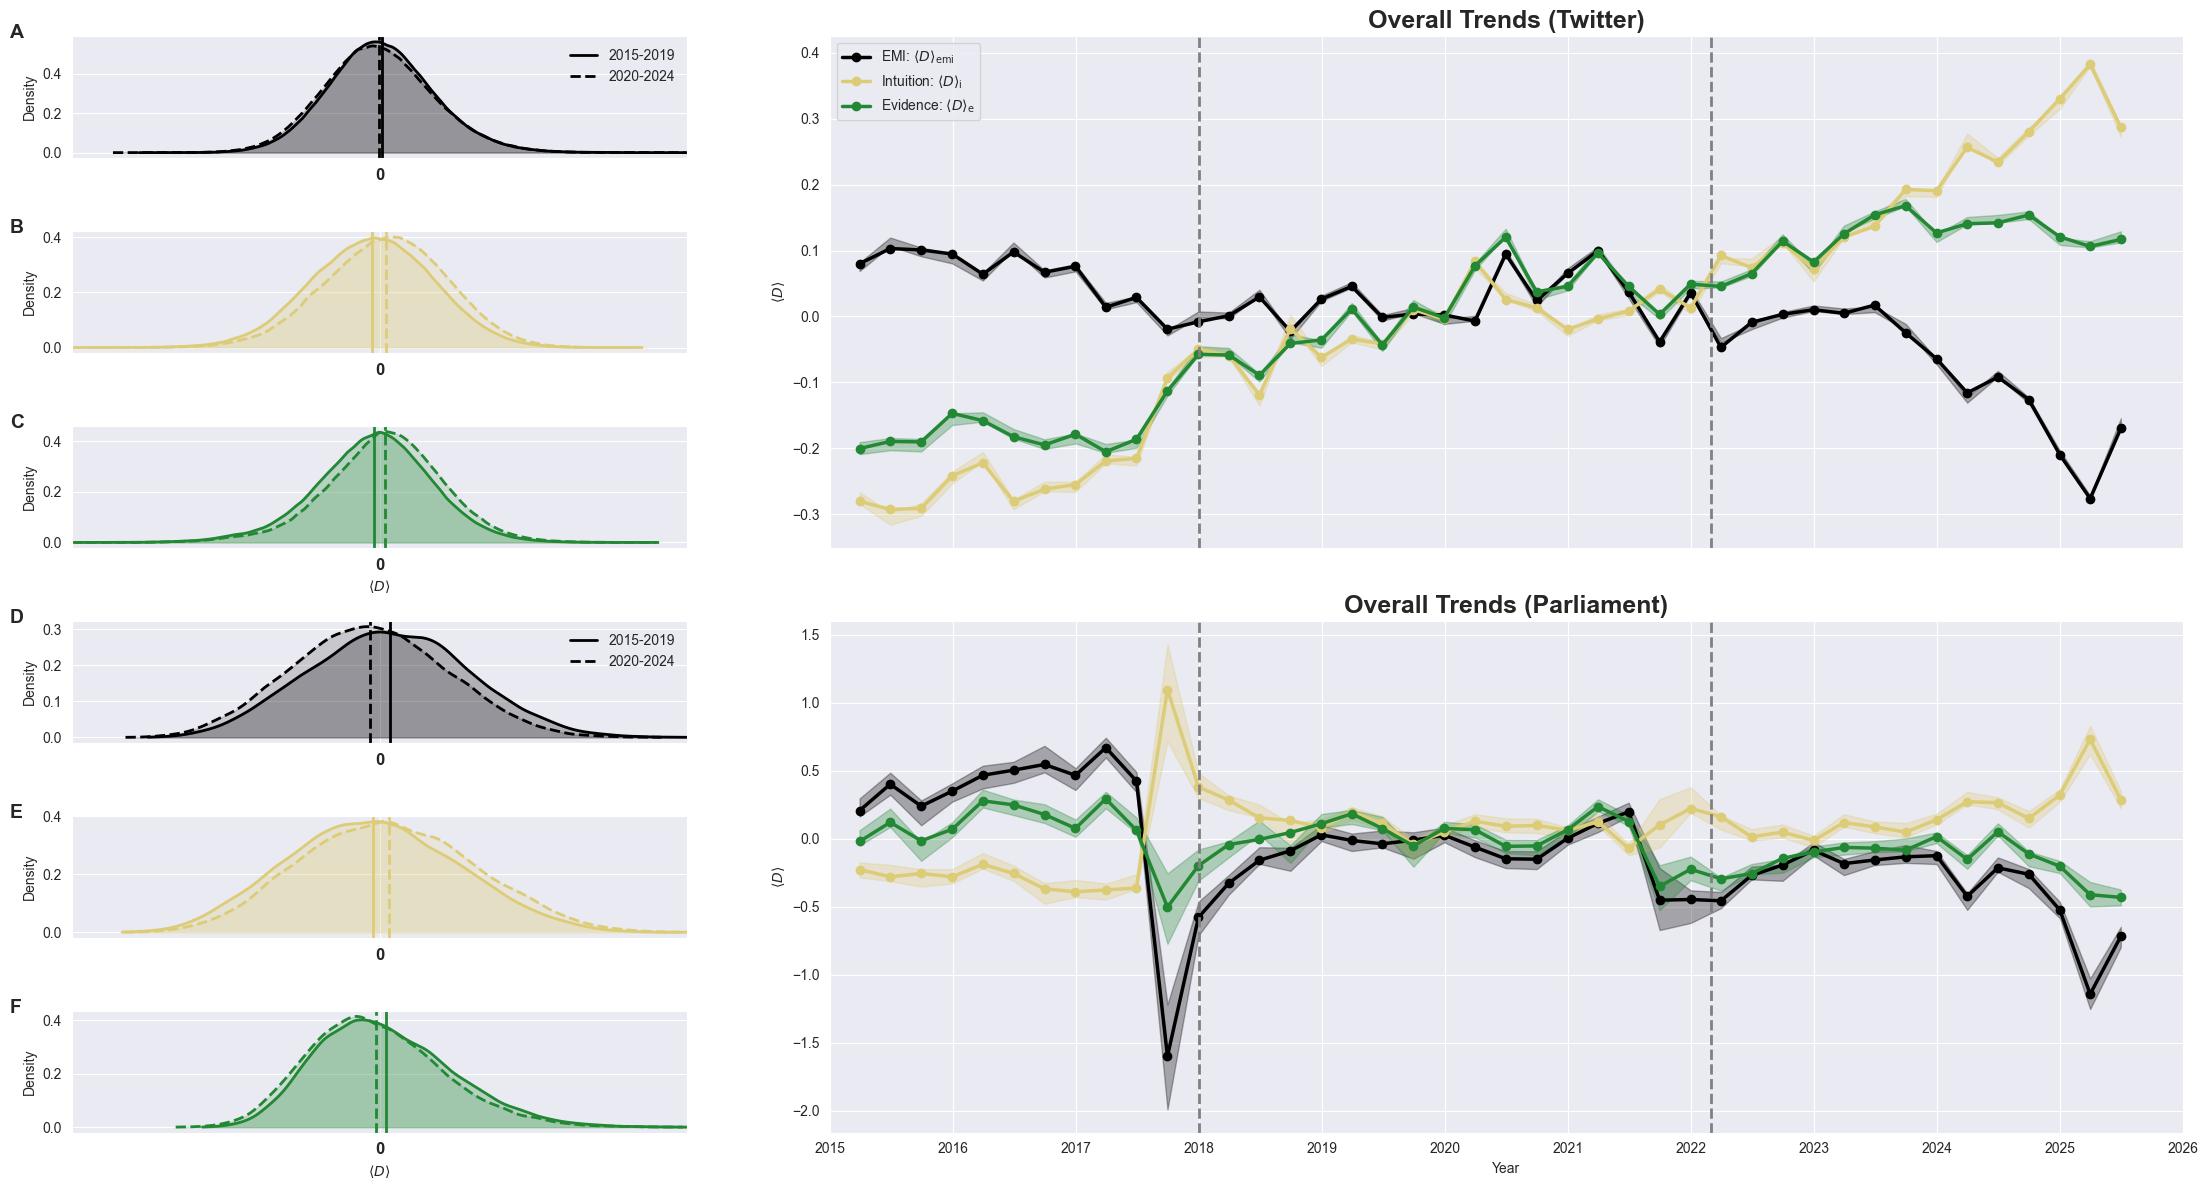

In [14]:
# === Preprocess ===
df_twitter["published_at"] = df_twitter["created_at"]
df_twitter["published_at"] = pd.to_datetime(df_twitter["published_at"]).dt.tz_localize(None)
df_twitter = df_twitter.sort_values("published_at")

df_parliament["date"] = pd.to_datetime(df_parliament["date"]).dt.tz_localize(None)
df_parliament = df_parliament.sort_values("date")

# === Common settings ===
columns = ["emi_w2vparliament", "intuition_z_w2vparliament", "evidence_z_w2vparliament"]
measure_titles = ["EMI", "Intuition", "Evidence"]
measure_colors = [black, red, blue]

periods = {
    "2015-2019": ("2015-01-01", "2019-12-31"),
    "2020-2024": ("2020-01-01", "2024-12-31")
}

period_styles = {
    "2015-2019": {"linestyle": "-", "alpha": 0.25},
    "2020-2024": {"linestyle": "--", "alpha": 0.15}
}

subplot_labels = ["A", "B", "C", "D", "E", "F"]

measures = {
    "emi_w2vparliament": {"color": black, "label": r"EMI: $\langle D \rangle_{\mathrm{emi}}$"},
    "intuition_z_w2vparliament": {"color": red, "label": r"Intuition: $\langle D \rangle_{\mathrm{i}}$"},
    "evidence_z_w2vparliament": {"color": blue, "label": r"Evidence: $\langle D \rangle_{\mathrm{e}}$"}
}

# === Create figure ===
fig = plt.figure(figsize=(24, 12))
gs = gridspec.GridSpec(6, 4, width_ratios=[0.7, 0.7, 4, 0.2])

# ============================================================
# === 1) Twitter density plots with both periods together ===
# ============================================================
for i, (col, title, color) in enumerate(zip(columns, measure_titles, measure_colors)):
    ax = plt.subplot(gs[i, 0:2])

    all_data = []

    for period_label, (start, end) in periods.items():
        data = df_twitter[
            (df_twitter["published_at"] >= start) &
            (df_twitter["published_at"] <= end)
        ][col].dropna()

        if len(data) > 1:
            x = np.linspace(data.min(), data.max(), 1000)
            kde = gaussian_kde(data)
            y = kde(x)

            ax.plot(
                x, y,
                color=color,
                linestyle=period_styles[period_label]["linestyle"],
                linewidth=2,
                label=period_label
            )
            ax.fill_between(
                x, 0, y,
                color=color,
                alpha=period_styles[period_label]["alpha"]
            )
            ax.axvline(
                data.mean(),
                color=color,
                linestyle=period_styles[period_label]["linestyle"],
                linewidth=2
            )

            all_data.append(data)

    if all_data:
        combined = pd.concat(all_data)
        lim = max(abs(combined.min()), abs(combined.max()))
        ax.set_xlim(-lim, lim)

    #ax.set_title(title, fontweight="bold")
    ax.set_xticks([0])
    ax.set_xticklabels(["0"], fontsize=12, fontweight="bold")
    ax.set_ylabel("Density")
    if i == 2:
        ax.set_xlabel(r"$\langle D \rangle$")

    ax.text(-0.1, 1.1, subplot_labels[i], transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top", ha="left")
    ax.grid(True, axis="x")

    if i == 0:
        ax.legend(frameon=False)

# === Twitter Timeline ===
ax_main1 = plt.subplot(gs[0:3, 2])
ax_main1.set_title("Overall Trends (Twitter)", fontweight="bold", fontsize=18)
ax_main1.grid(True, axis="x")

for col, params in measures.items():
    color = params["color"]
    label = params["label"]

    rolling = df_twitter.set_index("published_at")[col].rolling("60D", center=True).mean()
    avg = rolling.resample("Q").mean()

    bounds = [
        bootstrap_ci(
            df_twitter[df_twitter["published_at"].dt.to_period("Q") == q.to_period("Q")][col].dropna()
        )
        for q in avg.index
    ]
    lower, upper = zip(*bounds)

    ax_main1.plot(avg.index, avg, color=color, marker="o", linewidth=2.5, label=label)
    ax_main1.fill_between(avg.index, lower, upper, alpha=0.3, color=color)

ax_main1.axvline(pd.Timestamp("2018-01-01"), color="grey", linestyle="--", linewidth=2)
ax_main1.axvline(pd.Timestamp("2022-03-01"), color="grey", linestyle="--", linewidth=2)
ax_main1.set_ylabel(r"$\langle D \rangle$", fontweight="bold")
ax_main1.legend(loc="upper left")

# ============================================================
# === 2) Parliament density plots with both periods together ===
# ============================================================
for i, (col, title, color) in enumerate(zip(columns, measure_titles, measure_colors)):
    ax = plt.subplot(gs[i + 3, 0:2])

    all_data = []

    for period_label, (start, end) in periods.items():
        data = df_parliament[
            (df_parliament["date"] >= start) &
            (df_parliament["date"] <= end)
        ][col].dropna()

        if len(data) > 1:
            x = np.linspace(data.min(), data.max(), 1000)
            kde = gaussian_kde(data)
            y = kde(x)

            ax.plot(
                x, y,
                color=color,
                linestyle=period_styles[period_label]["linestyle"],
                linewidth=2,
                label=period_label
            )
            ax.fill_between(
                x, 0, y,
                color=color,
                alpha=period_styles[period_label]["alpha"]
            )
            ax.axvline(
                data.mean(),
                color=color,
                linestyle=period_styles[period_label]["linestyle"],
                linewidth=2
            )

            all_data.append(data)

    if all_data:
        combined = pd.concat(all_data)
        lim = max(abs(combined.min()), abs(combined.max()))
        ax.set_xlim(-lim, lim)

    ax.set_xticks([0])
    ax.set_xticklabels(["0"], fontsize=12, fontweight="bold")
    ax.set_ylabel("Density")
    if i == 2:
        ax.set_xlabel(r"$\langle D \rangle$")

    ax.text(-0.1, 1.1, subplot_labels[i + 3], transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top", ha="left")
    ax.grid(True, axis="x")

    if i == 0:
        ax.legend(frameon=False)

# === Parliament Timeline ===
ax_main2 = plt.subplot(gs[3:6, 2])
ax_main2.set_title("Overall Trends (Parliament)", fontweight="bold", fontsize=18)
ax_main2.grid(True, axis="x")

for col, params in measures.items():
    color = params["color"]
    label = params["label"]

    rolling = df_parliament.set_index("date")[col].rolling("60D", center=True).mean()
    avg = rolling.resample("Q").mean()

    bounds = [
        bootstrap_ci(
            df_parliament[df_parliament["date"].dt.to_period("Q") == q.to_period("Q")][col].dropna()
        )
        for q in avg.index
    ]
    lower, upper = zip(*bounds)

    ax_main2.plot(avg.index, avg, color=color, marker="o", linewidth=2.5, label=label)
    ax_main2.fill_between(avg.index, lower, upper, alpha=0.3, color=color)

ax_main2.axvline(pd.Timestamp("2018-01-01"), color="grey", linestyle="--", linewidth=2)
ax_main2.axvline(pd.Timestamp("2022-03-01"), color="grey", linestyle="--", linewidth=2)
ax_main2.set_ylabel(r"$\langle D \rangle$", fontweight="bold")
ax_main2.set_xlabel("Year")

# ============================================================
# === Sync x-axis across timelines ===
# ============================================================
xticks = pd.date_range(start="2015-01-01", end="2026-01-01", freq="YS")
xlim = (pd.Timestamp("2015-01-01"), pd.Timestamp("2026-01-01"))

for ax in [ax_main1, ax_main2]:
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)

ax_main1.set_xticklabels([])
ax_main2.set_xticklabels([str(t.year) for t in xticks])


# === Save + Show ===
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.savefig("results/rq1_combined_twitter_parliament_overlay.png", dpi=300)
plt.show()